In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
cols_order = [
     # Красная кровь
    'rbc',
    'hgb',
    'hct',
    'mcv',
    'mch',
    'mchc',
    'rdw',
    'rdv_cv',
    'rdv_sd',
    'ret_rel',
    'ret_abs',    
    'cp',
    'anisocytos',
    'hypochromia',
    'macrocytos',
    'microcytos',
    'poikilocytos',

    # Белая кровь
    'wbc',

    # Лейкоформула
    'ne_abs',
    'ne_rel',
    'ly_abs',
    'ly_rel',
    'mo_abs',
    'mo_rel',
    'eo_abs',
    'eo_rel',
    'ba_abs',
    'ba_rel',
    'pal',
    'seg',
    'mxd_abs',
    'mxd_rel',
    'plasma', # в норме - 0-1%

    # Тромбоциты
    'plt',
    'pct',
    'mpv',
    'pdw',
    'plcr',

    'soe',

    'myelo', # в норме - 0 появление в периферической крови всегда указывает на патологию
    'yunye', # в норме - 0 всегда требует обследования
    'blasty', # в норме - 0 опухолевые клетки, лейкоз
    'normoblast',
    'normobl_abs', # в норме - 0
    'normobl_rel', # в норме - 0
    'prolym', # в норме - 0 "красный флаг", требующий исключения злокачественных заболеваний крови!
    'promyelo', # в норме - 0  тревожный сигнал, требующий исключения лейкозов и других тяжелых заболеваний крови

    'noclass_abs',
    'noclass_rel',
]

In [3]:
flag_work_df = pd.read_csv('data/flag_work_df.csv')

In [4]:
display(flag_work_df.info())
display(flag_work_df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3115 entries, 0 to 3114
Data columns (total 52 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   study_ID      3115 non-null   object 
 1   gender        3115 non-null   int64  
 2   age           3115 non-null   int64  
 3   rbc           1498 non-null   float64
 4   hgb           1506 non-null   float64
 5   hct           1530 non-null   float64
 6   mcv           1549 non-null   float64
 7   mch           1551 non-null   float64
 8   mchc          1558 non-null   float64
 9   rdw           805 non-null    float64
 10  rdv_cv        683 non-null    float64
 11  rdv_sd        686 non-null    float64
 12  ret_rel       52 non-null     float64
 13  ret_abs       40 non-null     float64
 14  cp            802 non-null    float64
 15  anisocytos    970 non-null    float64
 16  hypochromia   245 non-null    float64
 17  macrocytos    141 non-null    float64
 18  microcytos    168 non-null  

None

,gender,age,rbc,hgb,hct,mcv,mch,mchc,rdw,rdv_cv,...,myelo,yunye,blasty,normoblast,normobl_abs,normobl_rel,prolym,promyelo,noclass_abs,noclass_rel
count,3115.000000,3115.000000,1498.000000,1506.000000,1530.000000,1549.000000,1551.000000,1558.000000,805.000000,683.000000,...,300.000000,291.000000,139.000000,5.0,179.000000,18.0,16.000000,19.000000,115.000000,237.000000
mean,0.518780,72.256822,-0.533378,-0.675963,-0.637255,-0.224661,-0.150870,-0.022465,0.398758,0.421669,...,0.993333,0.903780,0.992806,1.0,0.441341,0.0,0.187500,0.052632,0.243478,0.409283
std,0.499727,10.903332,0.645022,0.526929,0.599584,0.546198,0.405364,0.338319,0.492479,0.494188,...,0.081513,0.295401,0.084819,0.0,0.497940,0.0,0.403113,0.229416,0.431060,0.492742
min,0.000000,10.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.000000,...,0.000000,0.000000,0.000000,1.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
25%,0.000000,68.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,1.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
50%,1.000000,71.000000,-1.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,1.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
75%,1.000000,77.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.0,1.000000,0.0,0.000000,0.000000,0.000000,1.000000
max,1.000000,90.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.0,1.000000,0.0,1.000000,1.000000,1.000000,1.000000


## EDA

In [5]:

def check_data_quality(data,
                       freq_treshold=0.95,
                       nunique_threshold=0.95,
                       null_threshold=0):
    """Проводит поиск дублей, пропусков и неинформативных признаков и выводит результат в консоль.
    
    Неинформативным считается признак с долей уникальных значений или повторов выше установленного порога.
    
    Parameters
    ----------
        data : DataFrame
            Датафрейм для анализа
        freq_treshold : float
            Порог масимальной частоты встречаемости признака
        nunique_treshhold : float
            Порог максимальной уникальности признака
        null_threshold : float
            Порог максимального отстутсвия признака
    """
    
    # Поиск дублей
    try:
        print(f'Число найденных дублей: {
            data.duplicated().value_counts().loc[True]
            }\n')
    except KeyError:
        print('Количество дублей: 0\n')

    # Поиск пропущенных значений
    cols_null_percent = data.isnull().mean()
    cols_with_null = cols_null_percent[cols_null_percent > null_threshold]\
        .sort_values(ascending=False)
    if cols_with_null.shape[0]: display(cols_with_null)
    print(f'Количество признаков с пустыми значениями: {cols_with_null.shape[0]}\n')

    # Поиск неинформативных признаков
    low_information_cols = []
    bad_feat_flag = False
    # цикл по всем столбцам
    for col in data.columns:
        #наибольшая относительная частота в признаке
        top_freq = data[col].value_counts(normalize=True).max()
        #доля уникальных значений от размера признака
        nunique_ratio = data[col].nunique() / data[col].count()
        # сравниваем наибольшую частоту с порогом
        if top_freq > freq_treshold:
            bad_feat_flag = True
            low_information_cols.append(col)
            print(f'{col}: {top_freq:.2%} одинаковых значений')
        # сравниваем долю уникальных значений с порогом
        if nunique_ratio > nunique_threshold:
            bad_feat_flag = True
            low_information_cols.append(col)
            print(f'{col}: {nunique_ratio:.2%} уникальных значений')
    if not bad_feat_flag:
        print('Неинформативных признаков не найдено.')

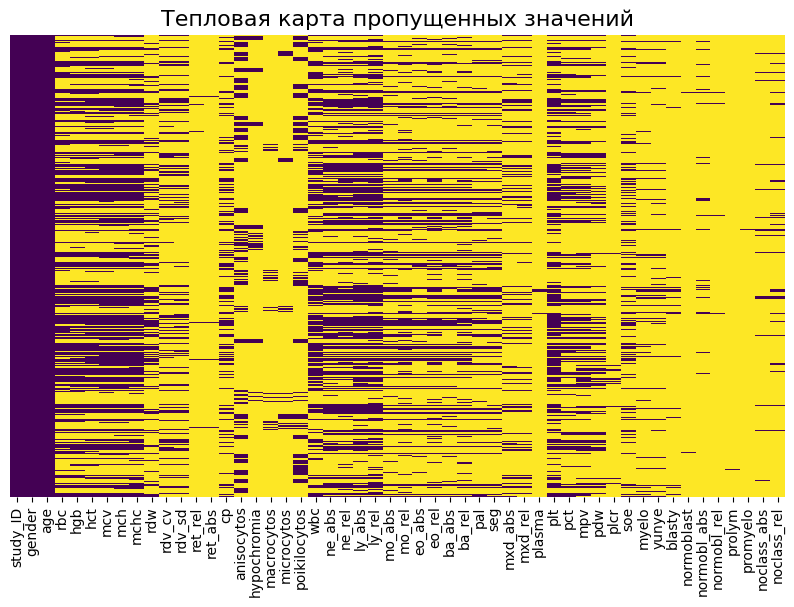

In [6]:
# Создаем тепловую карту пропусков
plt.figure(figsize=(10, 6))
sns.heatmap(flag_work_df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Тепловая карта пропущенных значений', fontsize=16)
plt.show()

In [7]:
flag_work_df[flag_work_df.isnull().sum(axis=1) < 10]

,study_ID,gender,age,rbc,hgb,hct,mcv,mch,mchc,rdw,...,myelo,yunye,blasty,normoblast,normobl_abs,normobl_rel,prolym,promyelo,noclass_abs,noclass_rel


In [8]:
leu_formula_list = ['ne_abs', 'ne_rel', 'ly_abs','ly_rel', 'mo_abs',
                    'mo_rel', 'eo_abs', 'eo_rel', 'ba_abs', 'ba_rel',
                    'pal', 'seg', 'mxd_abs', 'mxd_rel', 'plasma', # в норме - 0-1%
                    ]

# flag_work_df[leu_formula_list]

In [9]:
norm_null_list = ['plasma', 'myelo', 'yunye', 'blasty', 'normobl_abs',
                  'normobl_rel', 'prolym', 'promyelo', 'normoblast',
                  'plcr', 'noclass_abs', 'mxd_rel', 'mxd_abs', 'hypochromia',
                  'ret_abs', 'ret_rel', 'macrocytos', 'microcytos', 'noclass_rel',
                  'anisocytos', 'poikilocytos',
                  ]
# Заменим пустые значения но 0 (норма там где можно)
flag_work_df[norm_null_list] = flag_work_df[norm_null_list].fillna(0)

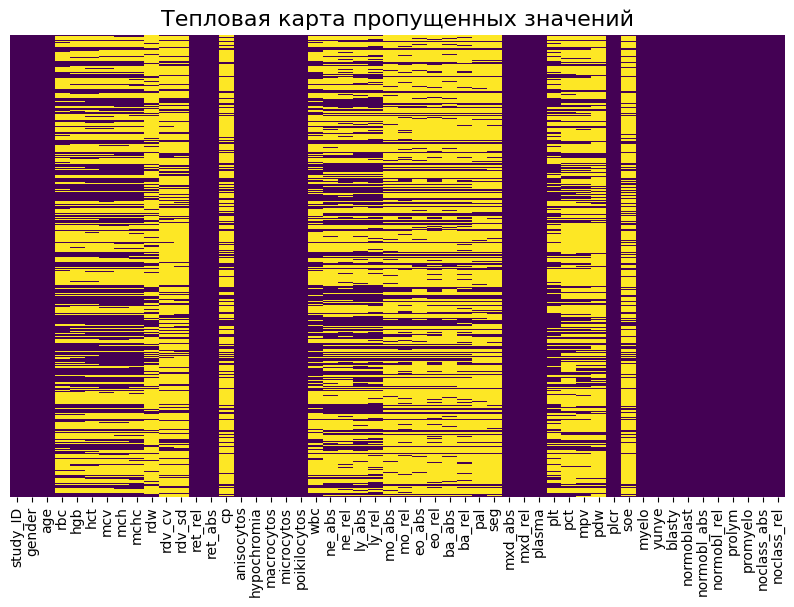

In [10]:
# Создаем тепловую карту пропусков
plt.figure(figsize=(10, 6))
sns.heatmap(flag_work_df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Тепловая карта пропущенных значений', fontsize=16)
plt.show()

In [11]:
flag_work_df[flag_work_df.isnull().sum(axis=1) < 10]

,study_ID,gender,age,rbc,hgb,hct,mcv,mch,mchc,rdw,...,myelo,yunye,blasty,normoblast,normobl_abs,normobl_rel,prolym,promyelo,noclass_abs,noclass_rel
0,05deb1af-cf40-11e9-80ba-901b0e633689_result_1802,0,87,-1.0,-1.0,-1.0,1.0,1.0,0.0,1.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,05deb1af-cf40-11e9-80ba-901b0e633689_result_1808,0,87,-1.0,-1.0,-1.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
38,0839c9c1-1109-11ef-8607-005056880ecb_result_2297,0,86,-1.0,-1.0,-1.0,-1.0,0.0,0.0,1.0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
44,0839c9c1-1109-11ef-8607-005056880ecb_result_2303,0,86,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
45,0839c9c1-1109-11ef-8607-005056880ecb_result_2304,0,86,0.0,0.0,0.0,0.0,0.0,0.0,NaN,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3101,ffa72572-f065-11ec-ab56-0050568844e6_result_1665,1,70,-1.0,-1.0,-1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3102,ffa72572-f065-11ec-ab56-0050568844e6_result_1666,1,70,-1.0,-1.0,-1.0,-1.0,-1.0,0.0,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3104,ffa72572-f065-11ec-ab56-0050568844e6_result_1670,1,70,-1.0,-1.0,-1.0,0.0,-1.0,0.0,1.0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3109,ffdf0ad3-bb5b-11ee-ab6f-0050568844e6_result_2590,1,71,-1.0,-1.0,-1.0,0.0,0.0,0.0,NaN,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
print('Проверка тренировочной выборки:'+'\n'+'-' * 30)
check_data_quality(flag_work_df)

Проверка тренировочной выборки:
------------------------------
Количество дублей: 0



pdw       0.791332
rdv_cv    0.780738
rdv_sd    0.779775
ba_abs    0.771429
pal       0.770465
seg       0.770144
eo_abs    0.769502
soe       0.757624
mo_abs    0.755377
cp        0.742536
rdw       0.741573
ba_rel    0.720064
pct       0.712360
eo_rel    0.696308
mpv       0.692456
mo_rel    0.687640
ne_abs    0.588764
ne_rel    0.587159
ly_abs    0.541894
wbc       0.525843
rbc       0.519101
hgb       0.516533
hct       0.508828
plt       0.503050
mcv       0.502729
mch       0.502087
mchc      0.499839
ly_rel    0.496308
dtype: float64

Количество признаков с пустыми значениями: 28

study_ID: 100.00% уникальных значений
ret_rel: 99.00% одинаковых значений
ret_abs: 99.17% одинаковых значений
macrocytos: 96.08% одинаковых значений
microcytos: 95.22% одинаковых значений
eo_rel: 96.62% одинаковых значений
plasma: 99.49% одинаковых значений
plcr: 100.00% одинаковых значений
blasty: 95.57% одинаковых значений
normoblast: 99.84% одинаковых значений
normobl_abs: 97.46% одинаковых значений
normobl_rel: 100.00% одинаковых значений
prolym: 99.90% одинаковых значений
promyelo: 99.97% одинаковых значений
noclass_abs: 99.10% одинаковых значений
noclass_rel: 96.89% одинаковых значений
